In [2]:
from quantum_part import *
from Bayesian_part import *
import random

import qutip as qt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.stats import norm
import torch
import gpytorch
from gpytorch.kernels import RBFKernel, ScaleKernel, MaternKernel, PolynomialKernel
from gpytorch.means import ZeroMean, ConstantMean
from gpytorch.distributions import MultivariateNormal
from botorch.models.gpytorch import GPyTorchModel
from torch.distributions import Bernoulli, Normal

In [3]:
############################# Definition of useful constants ##############################
############################################################################################
# definition for all the basis and pauli matrix
paulis = {
    "X": qt.sigmax(),
    "Y": qt.sigmay(),
    "Z": qt.sigmaz()
}

ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

pauli_eigen = {
    'Z': {+1: ket0, -1: ket1},
    'X': {+1: (ket0 + ket1).unit(),
          -1: (ket0 - ket1).unit()},
    'Y': {+1: (ket0 + 1j*ket1).unit(),
          -1: (ket0 - 1j*ket1).unit()}
}

############################################################################################
shadow_size = 300
qubit_num  = 2

In [5]:
# Define a quantum state plus
all_qubit = [(ket0+ket1).unit() for i in range(qubit_num)]
psi = qt.tensor(all_qubit)

# difine operator as \sigma_x \otimes \sigma_x \cdots for simplicity. estimations should be around 1
operator = qt.tensor(qt.sigmax(), qt.qeye(2))

rho = psi * psi.dag()
tlist = np.linspace(0, 2*np.pi, 1000)
####################################################################################
# definition of quantum dynamic
H = qt.tensor(qt.sigmaz(), qt.sigmaz())

# damping Hamiltonian model
gamma = 0.1
c_ops = [np.sqrt(gamma) * qt.tensor(qt.sigmaz(), qt.qeye(2))]

# result = qt.mesolve(H, psi, tlist, c_ops) # with damping
result = qt.mesolve(H, psi, tlist, []) # without damping

# expect = qt.expect(operator, result.states)

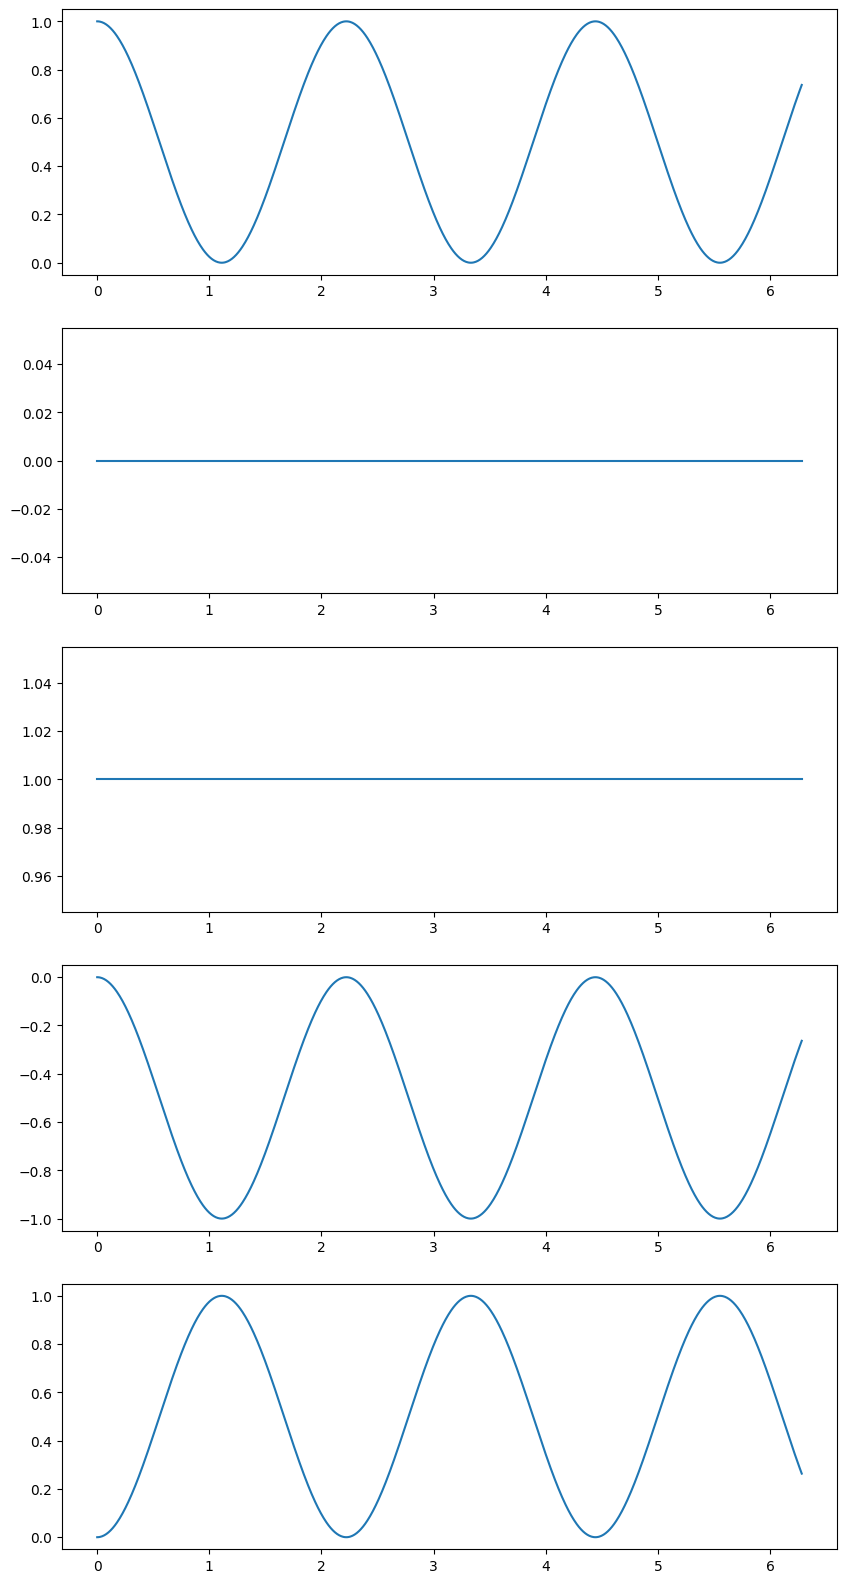

In [8]:
# New dynamics
# 1. Pure Ising
H = qt.tensor(qt.sigmaz(), qt.sigmaz())

# 2. Transverse-field Ising
H = (
    qt.tensor(qt.sigmaz(), qt.sigmaz())
    + 0.5 * (qt.tensor(qt.sigmax(), qt.qeye(2)) + qt.tensor(qt.qeye(2), qt.sigmax()))
)
result = qt.mesolve(H, psi, tlist, [])

operators = [
    qt.tensor(qt.sigmax(), qt.qeye(2)),
    qt.tensor(qt.sigmay(), qt.qeye(2)),
    qt.tensor(qt.sigmax(), qt.sigmax()),
    qt.tensor(qt.sigmay(), qt.sigmay()),
    qt.tensor(qt.sigmaz(), qt.sigmaz())
]

expect = [qt.expect(op, result.states) for op in operators]

fig, ax = plt.subplots(5,1, figsize=(10, 20))
for i in range(5):
    ax[i].plot(tlist, expect[i])
plt.show()
plt.close()

# Generation of data
This generate random outcome of pauli measurements at sparse time index. Datas are saved in measurement_df for further use.

In [5]:
indices = np.linspace(0, len(tlist) - 1, 200, dtype=int)
picked_times = tlist[indices]

# create variable name list for classical shadow
obs_list = []
for i in range(shadow_size):
    obs = create_random_pauli_obs(qubit_num)
    obs_list.append(obs)
records = []

for idx in indices:
    state_t = result.states[idx]
    rho = state_t if state_t.isoper else state_t * state_t.dag()
    # rho = result.states[idx] * result.states[idx].dag()
    time = tlist[idx]
    for shadow_id in range(shadow_size):
        obs = obs_list[shadow_id]
        measurements = pauli_measurement(rho, obs, qubit_num)

        for qubit, (pauli_label, outcome) in enumerate(measurements):
            records.append({
                # "time_idx": time_idx,
                "time": time,
                "shadow_id": shadow_id,
                "qubit": qubit,
                "pauli": pauli_label,
                "outcome": outcome,
            })

measurement_df = pd.DataFrame(records)

print(measurement_df)

            time  shadow_id  qubit pauli  outcome
0       0.000000          0      0     Z       -1
1       0.000000          0      1     Z        1
2       0.000000          1      0     Y        1
3       0.000000          1      1     Z        1
4       0.000000          2      0     Z       -1
...          ...        ...    ...   ...      ...
119995  6.283185        297      1     Z       -1
119996  6.283185        298      0     Z       -1
119997  6.283185        298      1     Y        1
119998  6.283185        299      0     X        1
119999  6.283185        299      1     Y        1

[120000 rows x 5 columns]


# Bayesian inference on shadow 
This part does Bayesian inference on separated shadow data. 

In [6]:
model_bank = train_conditional_gp_classifiers(
    measurement_df=measurement_df,
    qubit_num=qubit_num,
    shadow_ids=range(shadow_size),
)

shot_at_test_times = [[None for _ in range(shadow_size)] for _ in range(len(indices))]
for t_idx, idx in enumerate(indices):
    t_val = float(tlist[idx])
    for s_id in range(shadow_size):
        shot_at_test_times[t_idx][s_id] = simulate_classical_shadow_conditional(
            model_bank=model_bank,
            measurement_df=measurement_df,
            qubit_num=qubit_num,
            shadow_id=s_id,
            time_value=t_val,
        )


KeyboardInterrupt: 

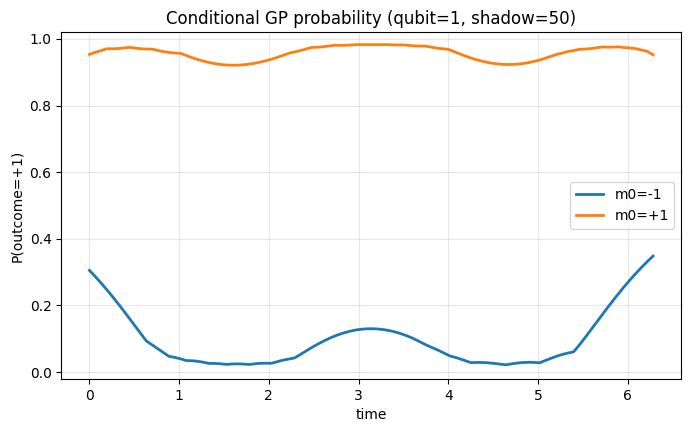

In [21]:
# Example: visualize qubit 1 (conditioned on qubit 0) for one shadow
fig, ax, curves = plot_conditional_probability_curves(
    model_bank=model_bank,
    qubit=1,
    shadow_id=50,
    t_values=tlist,
    measurement_df=measurement_df,   # lets function auto-pick observed conditioning patterns
)
plt.show()

In [15]:
from quantum_part import reconstruct_operator_dynamics_from_conditional_models

# choose reconstruction times (same as your picked indices)
recon_times = tlist #[indices]

results = reconstruct_operator_dynamics_from_conditional_models(
    model_bank=model_bank,
    measurement_df=measurement_df,
    qubit_num=qubit_num,
    operator=operator,
    time_points=recon_times,
    shadow_ids=range(shadow_size),   # optional; can omit
)

estimation_list = results["estimation"]   # reconstructed <operator>(t)
times = results["times"]


Reconstructing dynamics:   0%|          | 0/2000 [00:00<?, ?it/s]

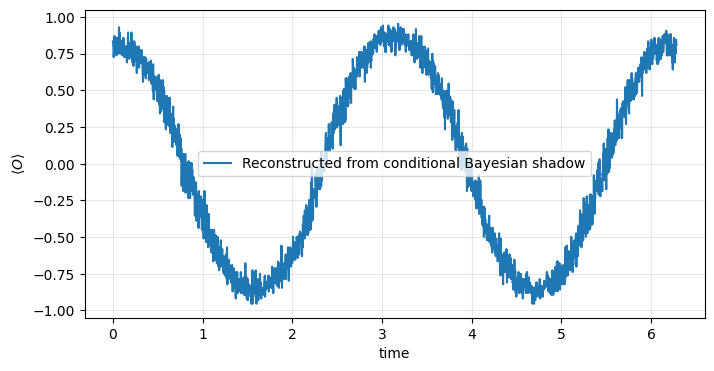

In [16]:
plt.figure(figsize=(8,4))
plt.plot(times, estimation_list, label="Reconstructed from conditional Bayesian shadow")
plt.xlabel("time")
plt.ylabel(r"$\langle O \rangle$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# Other Plots

In [81]:
# this part filters the shadow on the first qubit with measurement on X, and apply Bayesian inference on each shadow 
data = measurement_df[
    (measurement_df["qubit"] == 0) &
    (measurement_df["pauli"] == 'X')
]

print("Total data points:", len(data))

shadows = data["shadow_id"].unique()

prob_list = []
mu_list = []
var_list = []
original_shots_list = [] # this is for ploting

test_x = torch.tensor(tlist, dtype=torch.float32).unsqueeze(-1)

for s in shadows:

    shadow_data = data[data["shadow_id"] == s]
    if shadow_data.empty:
        continue

    train_x = torch.tensor(
        shadow_data["time"].to_numpy(),
        dtype=torch.float32
    ).unsqueeze(-1)

    train_y = torch.tensor(
        shadow_data["outcome"].to_numpy(),
        dtype=torch.float32
    )

    # ---- Train GP classifier ----
    model, likelihood = train_gp_classifier(train_x, train_y)

    # ---- Predict ----
    prob_star, mean_star, var_star = predict_gp_classifier(
        model, likelihood, test_x
    )

    plot_data = shadow_data.replace(-1,0)
    
    original_shots_list.append(plot_data)
    prob_list.append(prob_star)
    mu_list.append(mean_star)
    var_list.append(var_star)

Total data points: 36800


In [82]:
# real probabiility
plus = (ket0 + ket1).unit()
# plus = (ket0 + 1j*ket1).unit()
proj = qt.tensor(plus * plus.dag(), qt.qeye(2))
true_prob = [qt.expect(proj, psi) for psi in result.states]

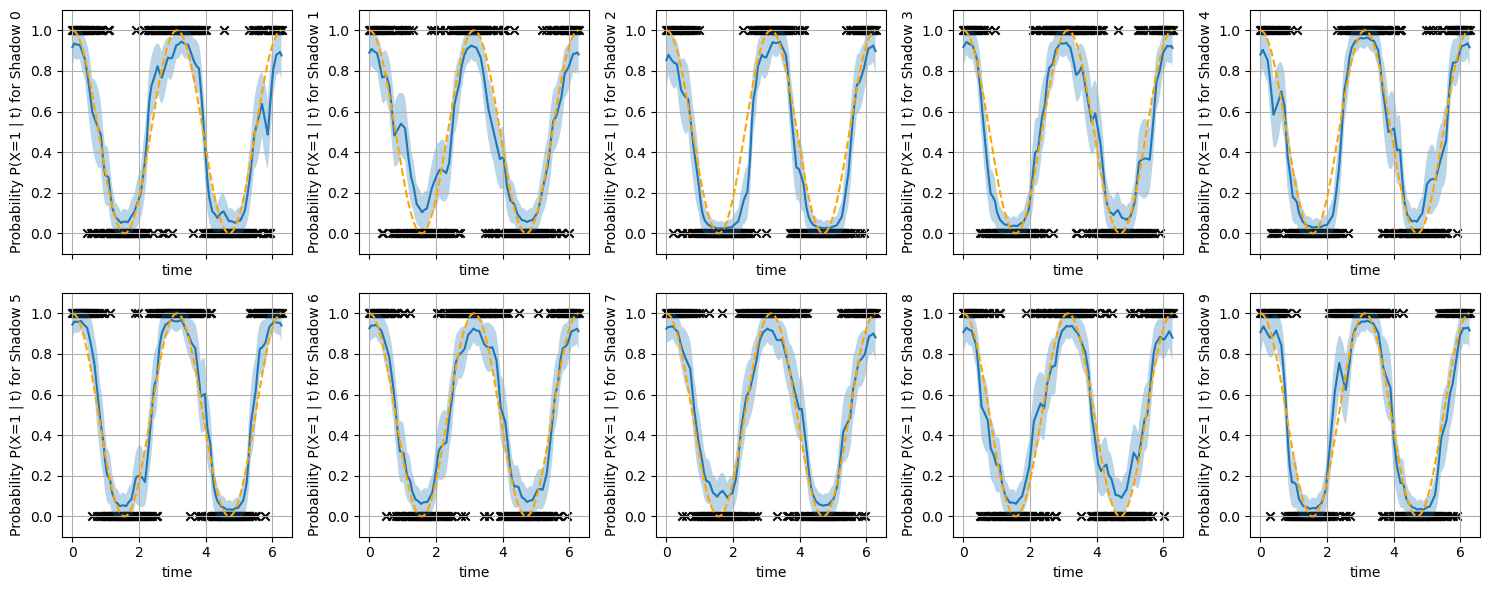

In [83]:
# plot the inference result of probability distribution on first 10 shadows
fig, axes = plt.subplots(2, 5, figsize=(15,6), sharex=True)

for i, ax in enumerate(axes.flatten()):

    mu = mu_list[i].detach().numpy()
    var = var_list[i].detach().numpy()

    # Predictive mean (Laplace-probit correction)
    prob_mean = norm.cdf(mu / np.sqrt(1 + var))

    # Delta-method propagated std
    # pdf_val = norm.pdf(mu)
    # prob_std = np.sqrt((pdf_val**2) * var)
    a = mu / np.sqrt(1 + var)

    pdf_val = norm.pdf(a)
    
    prob_var = (pdf_val**2) * (var / (1 + var))
    prob_std = np.sqrt(prob_var)

    # get original shot data
    data_for_plot = original_shots_list[i]
    

    ax.plot(tlist, prob_mean)
    ax.plot(tlist, true_prob, color = 'orange', linestyle='dashed')
    ax.scatter(data_for_plot['time'], data_for_plot['outcome'], color = 'black', marker = 'x')
    ax.fill_between(
        tlist,
        prob_mean - prob_std,
        prob_mean + prob_std,
        alpha=0.3
    )

    ax.set_ylabel(f"Probability P(X=1 | t) for Shadow {i}")
    ax.set_xlabel('time')
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True)

# axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()
plt.close()

# Accuracy Check

In [84]:
# ------------------------------------------------------------
# 2. Single-shot shadow reconstruction
# ------------------------------------------------------------
def single_shadow_rho_df(measurement_rows, qubit_num):
    """
    measurement_rows: dataframe slice corresponding to one shadow_id at one time
    """
    local_estimators = []

    for q in range(qubit_num):
        row = measurement_rows[measurement_rows["qubit"] == q].iloc[0]
        pauli = row["pauli"]
        outcome = row["outcome"]

        ket = pauli_eigen[pauli][outcome]
        proj = ket * ket.dag()

        local_estimators.append(3 * proj - qt.qeye(2))

    return qt.tensor(local_estimators)


# ------------------------------------------------------------
# 3. Classical shadow expectation estimation
# ------------------------------------------------------------
def classical_shadow_expectation_df(measurement_df, observable, qubit_num):
    """
    Computes classical shadow estimation of observable.

    Returns
    -------
    pd.DataFrame with columns:
        time
        expectation
    """

    results = []

    grouped = measurement_df.groupby(["time", "shadow_id"])

    temp_storage = {}

    for (time, shadow_id), group in grouped:
        rho_hat = single_shadow_rho_df(group, qubit_num)
        value = (observable * rho_hat).tr().real

        if time not in temp_storage:
            temp_storage[time] = []

        temp_storage[time].append(value)

    # Average over shadows for each time
    for time, values in temp_storage.items():
        results.append({
            "time": time,
            "expectation": np.mean(values)
        })

    # Convert to DataFrame and sort
    result_df = pd.DataFrame(results)
    result_df = result_df.sort_values("time").reset_index(drop=True)

    return result_df

In [85]:
shadow_estimates = classical_shadow_expectation_df(measurement_df, operator, qubit_num)

print(shadow_estimates)

         time  expectation
0    0.000000        1.104
1    0.031432        1.104
2    0.062863        1.104
3    0.094295        1.092
4    0.125727        1.092
..        ...          ...
195  6.154316        1.068
196  6.185747        1.080
197  6.217179        1.104
198  6.248611        1.092
199  6.283185        1.104

[200 rows x 2 columns]


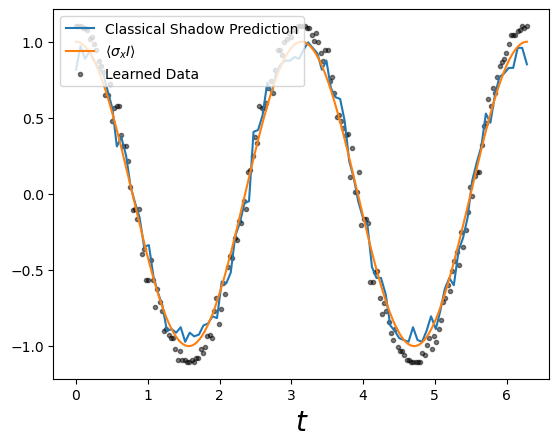

In [86]:
fig, axes = plt.subplots(1, 1)
expect = qt.expect(operator, result.states)
axes.plot(test_times, estimation_list, label='Classical Shadow Prediction')
axes.plot(tlist, expect, label=r"$\left<\sigma_x I\right>$")
axes.scatter(shadow_estimates['time'], shadow_estimates['expectation'],marker = '.', alpha = 0.5, c='black', label=r"Learned Data")
axes.set_xlabel(r"$t$", fontsize=20)
axes.legend(loc=2)
plt.show()
plt.close()

In [87]:
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel


def bayesian_regression_matern(
    result_df,
    nu=2.5,
    lengthscale_prior=None,
    train_noise=True,
    num_test_points=300,
    device="cpu",
):
    """
    Perform Bayesian regression using BoTorch with Matérn kernel.

    Parameters
    ----------
    result_df : pd.DataFrame
        Must contain columns:
            'time'
            'expectation'

    nu : float
        Smoothness parameter of Matérn kernel (0.5, 1.5, 2.5)

    train_noise : bool
        Whether to learn noise level

    num_test_points : int
        Number of prediction points

    Returns
    -------
    dict containing:
        model
        train_x
        train_y
        test_x
        posterior_mean
        posterior_var
    """

    # ----------------------------
    # Prepare training data
    # ----------------------------
    train_x = torch.tensor(
        result_df["time"].values,
        dtype=torch.double,
        device=device
    ).unsqueeze(-1)

    train_y = torch.tensor(
        result_df["expectation"].values,
        dtype=torch.double,
        device=device
    ).unsqueeze(-1)

    # ----------------------------
    # Define Matérn Kernel
    # ----------------------------
    covar_module = ScaleKernel(
        MaternKernel(nu=nu)
    )

    model = SingleTaskGP(
        train_X=train_x,
        train_Y=train_y,
        covar_module=covar_module
    )

    # ----------------------------
    # Fit model
    # ----------------------------
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    model.eval()

    # ----------------------------
    # Prediction grid
    # ----------------------------
    t_min = train_x.min().item()
    t_max = train_x.max().item()

    test_x = torch.linspace(
        t_min,
        t_max,
        num_test_points,
        dtype=torch.double,
        device=device
    ).unsqueeze(-1)

    with torch.no_grad():
        posterior = model.posterior(test_x)
        mean = posterior.mean.squeeze(-1)
        var = posterior.variance.squeeze(-1)

    return {
        "model": model,
        "train_x": train_x,
        "train_y": train_y,
        "test_x": test_x,
        "posterior_mean": mean,
        "posterior_var": var,
    }

In [88]:
gp_results = bayesian_regression_matern(shadow_estimates)

mean = gp_results["posterior_mean"].cpu().numpy()
var = gp_results["posterior_var"].cpu().numpy()
test_x = gp_results["test_x"].cpu().numpy()

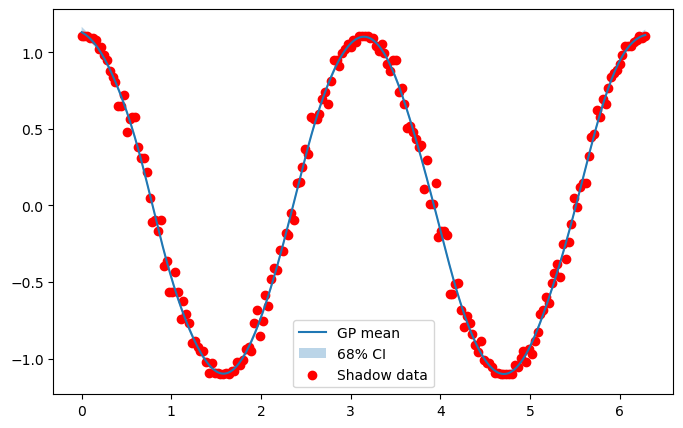

In [89]:

mean_np = mean
std_np = np.sqrt(var)

plt.figure(figsize=(8,5))
plt.plot(test_x, mean_np, label="GP mean")
plt.fill_between(
    test_x.flatten(),
    mean_np - std_np,
    mean_np + std_np,
    alpha=0.3,
    label="68% CI"
)

plt.scatter(
    shadow_estimates["time"],
    shadow_estimates["expectation"],
    color="red",
    label="Shadow data"
)

plt.legend()
plt.show()

In [90]:
def compute_trust_zone(all_probs, all_vars, confidence=0.95):
    """
    Compute trust zone over shadows for each qubit and time.

    Parameters
    ----------
    all_probs : (Q, S, T)
        Predicted probabilities
    all_vars : (Q, S, T)
        Predictive variances from GP
    confidence : float
        Confidence level (default 0.95)

    Returns
    -------
    mean_overall : (Q, T)
    lower_bound  : (Q, T)
    upper_bound  : (Q, T)
    total_var    : (Q, T)
    """

    # ---- Mean over shadows ----
    mean_overall = all_probs.mean(dim=1)  # (Q, T)

    # ---- Model uncertainty term ----
    mean_model_var = all_vars.mean(dim=1)  # (Q, T)

    # ---- Shadow variability term ----
    var_shadow = all_probs.var(dim=1, unbiased=False)  # (Q, T)

    # ---- Total variance ----
    total_var = mean_model_var + var_shadow

    std_total = torch.sqrt(total_var)

    # z-score
    if confidence == 0.95:
        z = 1.96
    elif confidence == 0.68:
        z = 1.0
    else:
        from scipy.stats import norm
        z = norm.ppf((1 + confidence) / 2)

    lower_bound = mean_overall - z * std_total
    upper_bound = mean_overall + z * std_total

    return mean_overall, lower_bound, upper_bound, total_var

In [91]:
mean_q, lower_q, upper_q, total_var = compute_trust_zone(
    all_probs,
    all_vars,
    confidence=0.68
)

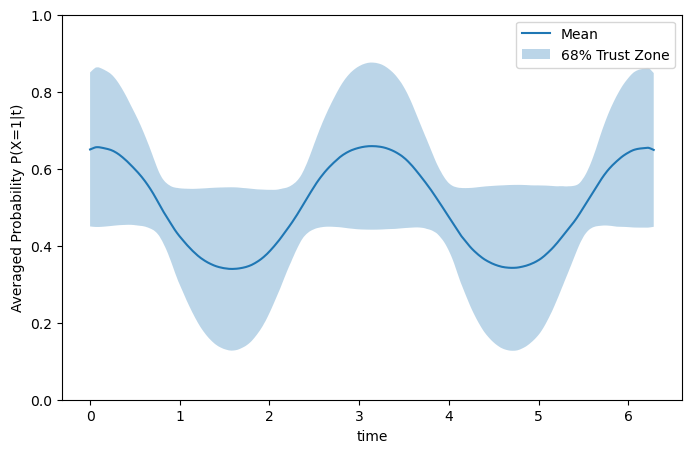

In [92]:
q = 0  # choose qubit

plt.figure(figsize=(8,5))

plt.plot(tlist, mean_q[q].numpy(), label="Mean")

plt.fill_between(
    tlist,
    lower_q[q].numpy(),
    upper_q[q].numpy(),
    alpha=0.3,
    label="68% Trust Zone"
)
plt.ylim(0,1)
plt.xlabel('time')
plt.ylabel('Averaged Probability P(X=1|t)')
plt.legend()
plt.show()